Preprocessing

In [64]:
import warnings
warnings.filterwarnings('ignore')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from imblearn.over_sampling import SMOTE

from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_score, adjusted_rand_score

from scipy.cluster.hierarchy import linkage, dendrogram, fcluster
from sklearn.metrics import adjusted_rand_score

from sklearn.manifold import TSNE
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    roc_curve,
    ConfusionMatrixDisplay
)
from xgboost import XGBClassifier
import shap
import time
from sklearn.linear_model import LogisticRegression


Loading Data

In [3]:
cols = [
    'age', 'sex', 'cp', 'trestbps', 'chol', 'fbs',
    'restecg', 'thalach', 'exang', 'oldpeak',
    'slope', 'ca', 'thal', 'target'
]

df = pd.read_csv("processed.cleveland.data", header=None, names=cols)   # change filename if needed

df = df.replace('?', np.nan)

df = df.dropna()

df = df.apply(pd.to_numeric)

df['target'] = (df['target'] > 0).astype(int)

print(df.head())
print(df['target'].value_counts())

print("Original Shape:", df.shape)   

print("\nFirst 5 Rows:")
print(df.head())

print("\nData Types:")
print(df.dtypes)

    age  sex   cp  trestbps   chol  fbs  restecg  thalach  exang  oldpeak  \
0  63.0  1.0  1.0     145.0  233.0  1.0      2.0    150.0    0.0      2.3   
1  67.0  1.0  4.0     160.0  286.0  0.0      2.0    108.0    1.0      1.5   
2  67.0  1.0  4.0     120.0  229.0  0.0      2.0    129.0    1.0      2.6   
3  37.0  1.0  3.0     130.0  250.0  0.0      0.0    187.0    0.0      3.5   
4  41.0  0.0  2.0     130.0  204.0  0.0      2.0    172.0    0.0      1.4   

   slope   ca  thal  target  
0    3.0  0.0   6.0       0  
1    2.0  3.0   3.0       1  
2    2.0  2.0   7.0       1  
3    3.0  0.0   3.0       0  
4    1.0  0.0   3.0       0  
target
0    160
1    137
Name: count, dtype: int64
Original Shape: (297, 14)

First 5 Rows:
    age  sex   cp  trestbps   chol  fbs  restecg  thalach  exang  oldpeak  \
0  63.0  1.0  1.0     145.0  233.0  1.0      2.0    150.0    0.0      2.3   
1  67.0  1.0  4.0     160.0  286.0  0.0      2.0    108.0    1.0      1.5   
2  67.0  1.0  4.0     120.0  229.0

Handling missing values

In [4]:
df = df.replace('?', np.nan)

missing_cols = df.columns[df.isna().any()]

print("\nColumns with missing values:")
for col in missing_cols:
    print(f"{col}: {df[col].isna().sum()} missing")

rows_with_missing = df.isna().any(axis=1).sum()
print("\nRows containing missing values:", rows_with_missing)

df = df.dropna()

print("Shape after dropping missing rows:", df.shape)
print("Final retained row count:", len(df))


Columns with missing values:

Rows containing missing values: 0
Shape after dropping missing rows: (297, 14)
Final retained row count: 297


In [5]:
for col in df.columns:
    df[col] = pd.to_numeric(df[col])


TARGET CLASS DISTRIBUTION

In [6]:
target_counts = df['target'].value_counts().sort_index()
target_percent = df['target'].value_counts(normalize=True).sort_index() * 100

print("\nTarget Class Distribution:")
for cls in target_counts.index:
    print(f"Class {cls}: {target_counts[cls]} ({target_percent[cls]:.2f}%)")

# Brief balance check
minority_ratio = target_counts.min() / target_counts.max()

if minority_ratio < 0.80:
    print("\nDataset is moderately imbalanced.")
    use_smote = True
else:
    print("\nDataset is reasonably balanced.")
    use_smote = False


Target Class Distribution:
Class 0: 160 (53.87%)
Class 1: 137 (46.13%)

Dataset is reasonably balanced.


TRAIN / TEST SPLIT (before scaling)

In [7]:
X = df.drop('target', axis=1)
y = df['target']

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("\nTrain shape:", X_train.shape)
print("Test shape :", X_test.shape)



Train shape: (237, 13)
Test shape : (60, 13)


ENCODING + STANDARDIZATION

In [8]:
categorical_cols = ['cp', 'restecg', 'slope', 'thal']
continuous_cols = ['age', 'trestbps', 'chol', 'thalach', 'oldpeak', 'ca']

# One-hot encode
X_train = pd.get_dummies(X_train, columns=categorical_cols, drop_first=True)
X_test = pd.get_dummies(X_test, columns=categorical_cols, drop_first=True)

# Align test columns with training columns
X_train, X_test = X_train.align(X_test, join='left', axis=1, fill_value=0)

# Standardize continuous columns (fit only on training set)
scaler = StandardScaler()

X_train[continuous_cols] = scaler.fit_transform(X_train[continuous_cols])
X_test[continuous_cols] = scaler.transform(X_test[continuous_cols])

APPLY SMOTE ONLY ON TRAINING SPLIT

In [9]:
if use_smote:
    smote = SMOTE(random_state=42)
    X_train, y_train = smote.fit_resample(X_train, y_train)

    print("\nAfter SMOTE:")
    print(pd.Series(y_train).value_counts())

CORRELATION HEATMAP (before encoding)

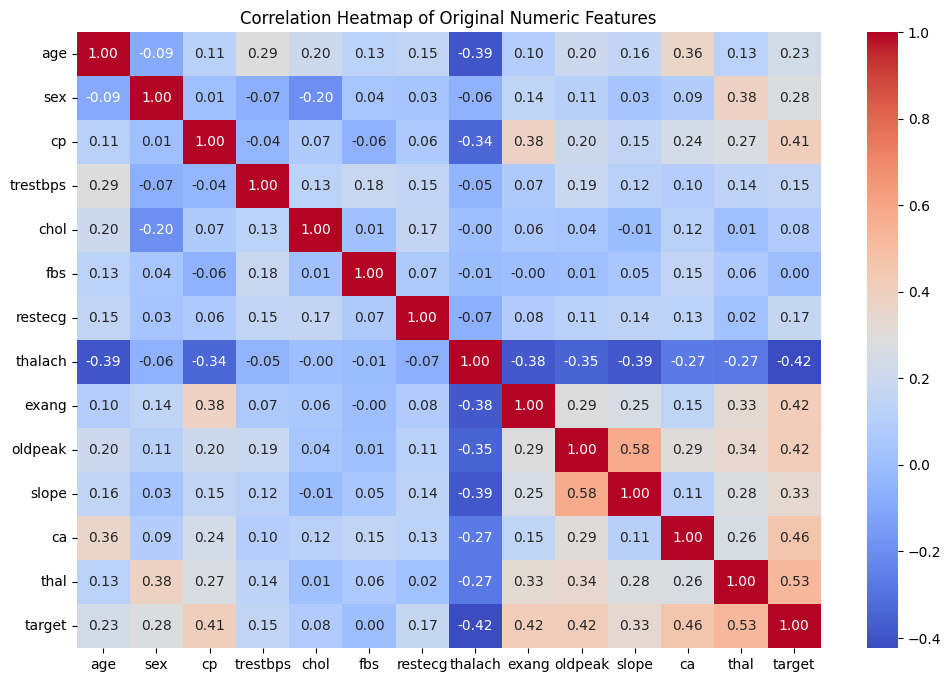

In [10]:
numeric_df = df.select_dtypes(include=np.number)

plt.figure(figsize=(12, 8))
sns.heatmap(numeric_df.corr(), annot=True, cmap='coolwarm', fmt=".2f")
plt.title("Correlation Heatmap of Original Numeric Features")
plt.show()

TOP 3 STRONGEST CORRELATIONS

In [11]:
corr_matrix = numeric_df.corr().abs()

upper = corr_matrix.where(np.triu(np.ones(corr_matrix.shape), k=1).astype(bool))

top_pairs = upper.unstack().dropna().sort_values(ascending=False)

print("\nTop 3 Strongest Correlated Feature Pairs:")
for i in range(3):
    pair = top_pairs.index[i]
    value = top_pairs.iloc[i]
    print(f"{pair[0]} - {pair[1]} : {value:.3f}")


Top 3 Strongest Correlated Feature Pairs:
slope - oldpeak : 0.579
target - thal : 0.527
target - ca : 0.463


Part A

A1 

FULL FEATURE MATRIX (without target)

In [17]:
X_full = df.drop('target', axis=1)
y_true = df['target']

# Standardize full feature matrix
scaler_unsup = StandardScaler()
X_scaled = scaler_unsup.fit_transform(X_full)

K-MEANS FOR k = 2..8

In [18]:
k_values = range(2, 9)
wcss = []
sil_scores = []

for k in k_values:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = kmeans.fit_predict(X_scaled)

    wcss.append(kmeans.inertia_)
    sil_scores.append(silhouette_score(X_scaled, labels))

chosing K 

In [19]:
best_k = k_values[np.argmax(sil_scores)]

print("WCSS values:")
for k, val in zip(k_values, wcss):
    print(f"k={k}: {val:.2f}")

print("\nSilhouette Scores:")
for k, val in zip(k_values, sil_scores):
    print(f"k={k}: {val:.4f}")

print(f"\nChosen k = {best_k}")

WCSS values:
k=2: 3193.45
k=3: 2931.15
k=4: 2743.77
k=5: 2609.80
k=6: 2507.28
k=7: 2404.55
k=8: 2318.45

Silhouette Scores:
k=2: 0.1751
k=3: 0.1298
k=4: 0.1304
k=5: 0.1127
k=6: 0.1137
k=7: 0.1013
k=8: 0.1060

Chosen k = 2


Plot WCSS + Silhouette

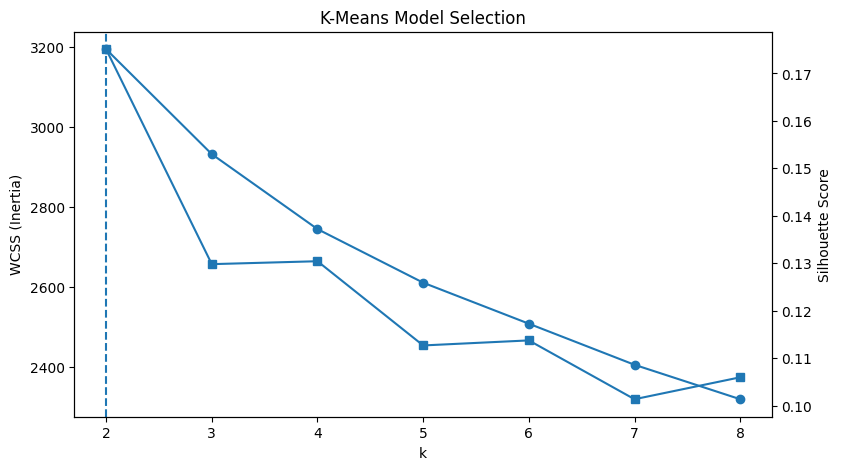

In [20]:
fig, ax1 = plt.subplots(figsize=(9, 5))

ax1.plot(k_values, wcss, marker='o')
ax1.set_xlabel("k")
ax1.set_ylabel("WCSS (Inertia)")

ax2 = ax1.twinx()
ax2.plot(k_values, sil_scores, marker='s')
ax2.set_ylabel("Silhouette Score")

ax1.axvline(best_k, linestyle='--')

plt.title("K-Means Model Selection")
plt.show()


FINAL K-MEANS WITH CHOSEN k

In [21]:
kmeans_final = KMeans(n_clusters=best_k, random_state=42, n_init=10)
cluster_labels = kmeans_final.fit_predict(X_scaled)

PCA TO 2D

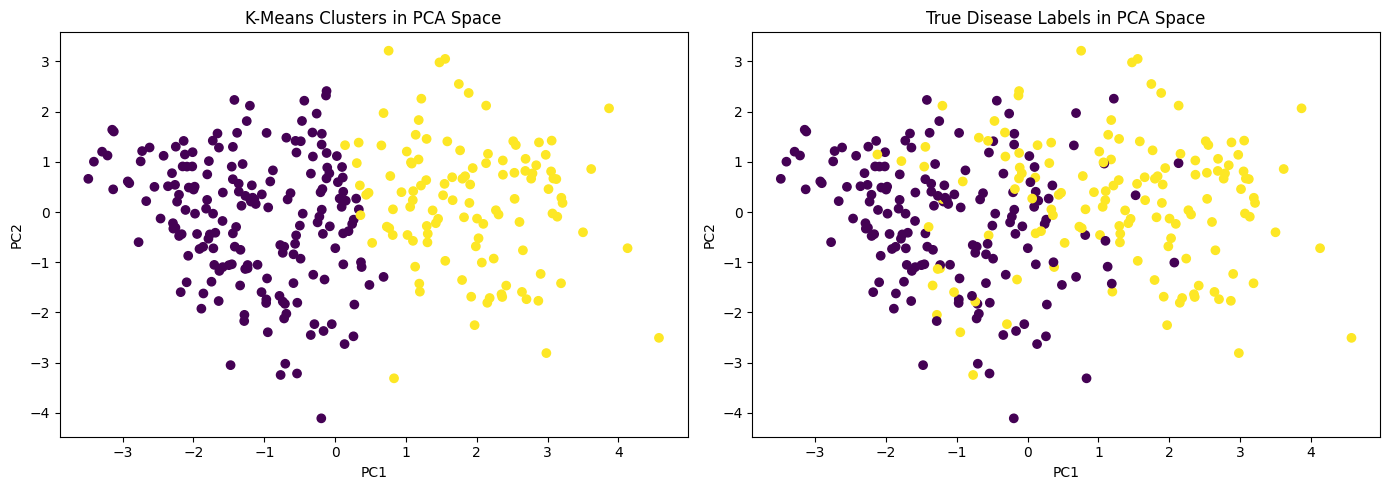

In [22]:
pca = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(X_scaled)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Cluster labels
axes[0].scatter(X_pca[:, 0], X_pca[:, 1], c=cluster_labels)
axes[0].set_title("K-Means Clusters in PCA Space")
axes[0].set_xlabel("PC1")
axes[0].set_ylabel("PC2")

# True labels
axes[1].scatter(X_pca[:, 0], X_pca[:, 1], c=y_true)
axes[1].set_title("True Disease Labels in PCA Space")
axes[1].set_xlabel("PC1")
axes[1].set_ylabel("PC2")

plt.tight_layout()
plt.show()


CLUSTER SUMMARY TABLE

In [23]:
summary_df = X_full.copy()
summary_df['target'] = y_true
summary_df['cluster'] = cluster_labels

cluster_summary = summary_df.groupby('cluster').agg(
    cluster_size=('target', 'count'),
    heart_disease_proportion=('target', 'mean'),
    thalach_mean=('thalach', 'mean'),
    oldpeak_mean=('oldpeak', 'mean'),
    cp_mean=('cp', 'mean')
)

print("\nCluster Summary:")
print(cluster_summary)


Cluster Summary:
         cluster_size  heart_disease_proportion  thalach_mean  oldpeak_mean  \
cluster                                                                       
0                 184                  0.201087    159.880435      0.542935   
1                 113                  0.884956    132.858407      1.890265   

          cp_mean  
cluster            
0        2.782609  
1        3.769912  


SIMPLE CLINICAL PROFILES

In [24]:
for c in sorted(summary_df['cluster'].unique()):
    subset = summary_df[summary_df['cluster'] == c]

    print(f"\nCluster {c} profile:")
    print(f"Size = {len(subset)}")
    print(f"Heart disease proportion = {subset['target'].mean():.2f}")
    print(f"Mean thalach = {subset['thalach'].mean():.2f}")
    print(f"Mean oldpeak = {subset['oldpeak'].mean():.2f}")
    print(f"Mean cp = {subset['cp'].mean():.2f}")



Cluster 0 profile:
Size = 184
Heart disease proportion = 0.20
Mean thalach = 159.88
Mean oldpeak = 0.54
Mean cp = 2.78

Cluster 1 profile:
Size = 113
Heart disease proportion = 0.88
Mean thalach = 132.86
Mean oldpeak = 1.89
Mean cp = 3.77


ADJUSTED RAND INDEX

In [25]:
ari = adjusted_rand_score(y_true, cluster_labels)

print(f"\nAdjusted Rand Index (ARI): {ari:.4f}")


Adjusted Rand Index (ARI): 0.4380


A2

WARD LINKAGE

In [26]:
Z = linkage(X_scaled, method='ward')

DENDROGRAM (TOP 25 MERGES)

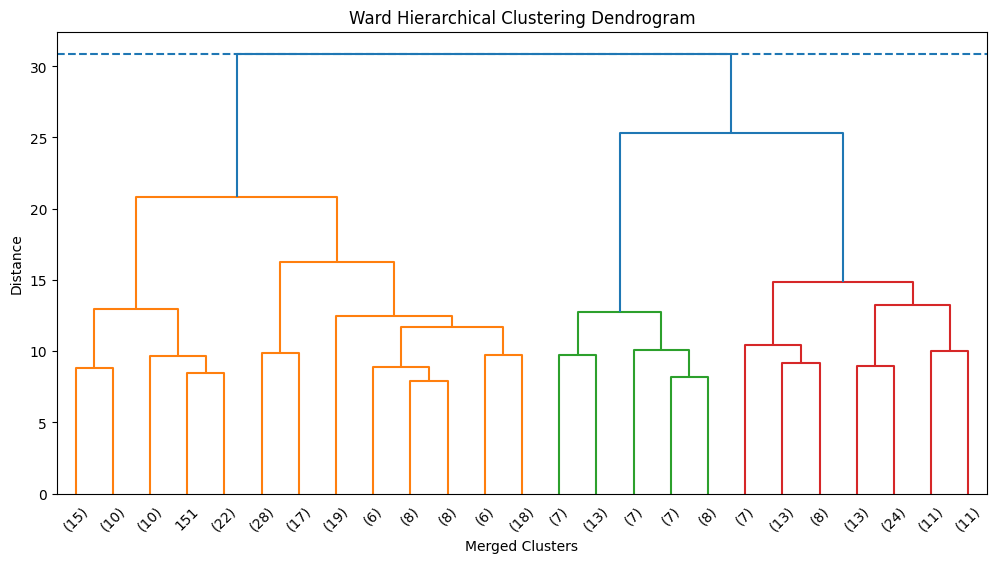

Chosen cut height: 30.891
Resulting number of clusters: 2


In [27]:
plt.figure(figsize=(12, 6))

dendrogram(
    Z,
    truncate_mode='lastp',
    p=25,
    show_leaf_counts=True
)

# Using same number of clusters asin K-Means
n_clusters_h = best_k

# Recommended cut height
cut_height = Z[-(n_clusters_h - 1), 2]

plt.axhline(y=cut_height, linestyle='--')

plt.title("Ward Hierarchical Clustering Dendrogram")
plt.xlabel("Merged Clusters")
plt.ylabel("Distance")
plt.show()

print(f"Chosen cut height: {cut_height:.3f}")
print(f"Resulting number of clusters: {n_clusters_h}")

CUT TREE

In [28]:
h_labels = fcluster(Z, t=n_clusters_h, criterion='maxclust')

CLUSTER vs TRUE LABEL CROSSTAB

In [29]:
crosstab = pd.crosstab(
    h_labels,
    y_true,
    rownames=['Hierarchical Cluster'],
    colnames=['Disease Label']
)

print("\nCluster–Label Crosstab:")
print(crosstab)



Cluster–Label Crosstab:
Disease Label           0   1
Hierarchical Cluster         
1                     117  51
2                      43  86


HIERARCHICAL vs K-MEANS ARI

In [30]:
ari_h_vs_k = adjusted_rand_score(cluster_labels, h_labels)

print(f"\nARI (Hierarchical vs K-Means): {ari_h_vs_k:.4f}")


ARI (Hierarchical vs K-Means): 0.3688


A3

PCA — EXPLAINED VARIANCE

Explained variance ratio per component:
PC1: 0.2370
PC2: 0.1235
PC3: 0.0960
PC4: 0.0852
PC5: 0.0764
PC6: 0.0672
PC7: 0.0649
PC8: 0.0599
PC9: 0.0527
PC10: 0.0437
PC11: 0.0349
PC12: 0.0314
PC13: 0.0272

Components needed for 90% explained variance: 10


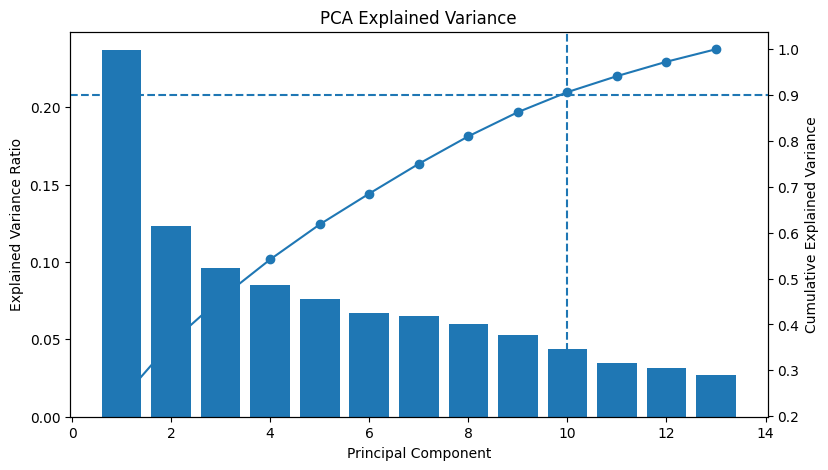

In [32]:
pca_full = PCA()
pca_full.fit(X_scaled)

explained_var = pca_full.explained_variance_ratio_
cum_var = np.cumsum(explained_var)

# Components needed for 90% variance
n_components_90 = np.argmax(cum_var >= 0.90) + 1

print("Explained variance ratio per component:")
for i, var in enumerate(explained_var, start=1):
    print(f"PC{i}: {var:.4f}")

print(f"\nComponents needed for 90% explained variance: {n_components_90}")

# Plot explained variance + cumulative variance
fig, ax1 = plt.subplots(figsize=(9, 5))

components = np.arange(1, len(explained_var) + 1)

ax1.bar(components, explained_var)
ax1.set_xlabel("Principal Component")
ax1.set_ylabel("Explained Variance Ratio")

ax2 = ax1.twinx()
ax2.plot(components, cum_var, marker='o')
ax2.set_ylabel("Cumulative Explained Variance")

ax2.axhline(0.90, linestyle='--')
ax1.axvline(n_components_90, linestyle='--')

plt.title("PCA Explained Variance")
plt.show()

t-SNE

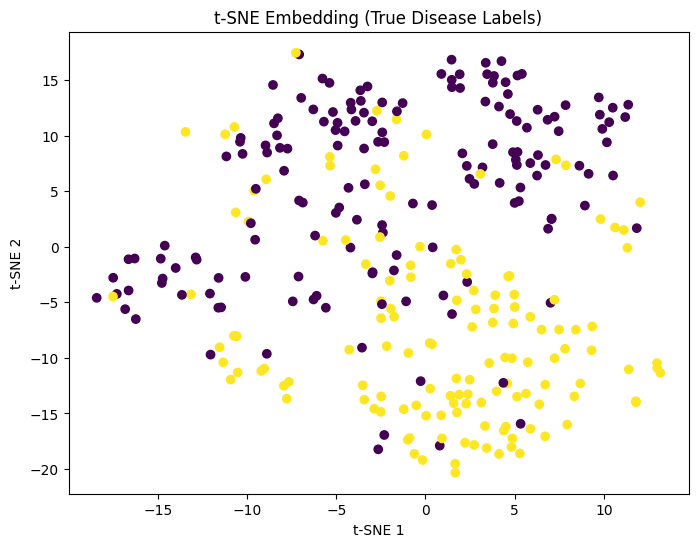

In [35]:
tsne = TSNE(
    n_components=2,
    perplexity=30,
    random_state=42
)

X_tsne = tsne.fit_transform(X_scaled)

plt.figure(figsize=(8, 6))
plt.scatter(X_tsne[:, 0], X_tsne[:, 1], c=y_true)
plt.title("t-SNE Embedding (True Disease Labels)")
plt.xlabel("t-SNE 1")
plt.ylabel("t-SNE 2")
plt.show()

Part B— RANDOM FOREST (BAGGING)

PART B1 

GRID SEARCH (5-FOLD CV)

In [37]:
param_grid = {
    'n_estimators': [50, 100, 200],
    'max_depth': [None, 5, 10]
}

rf_grid = GridSearchCV(
    RandomForestClassifier(
        random_state=42,
        oob_score=True
    ),
    param_grid=param_grid,
    scoring='f1_macro',
    cv=5,
    n_jobs=-1
)

rf_grid.fit(X_train, y_train)

best_rf = rf_grid.best_estimator_

print("Best Parameters:", rf_grid.best_params_)
print("Best Mean CV F1:", rf_grid.best_score_)

Best Parameters: {'max_depth': 5, 'n_estimators': 100}
Best Mean CV F1: 0.8182497710638803


OOB ERROR vs NUMBER OF TREES

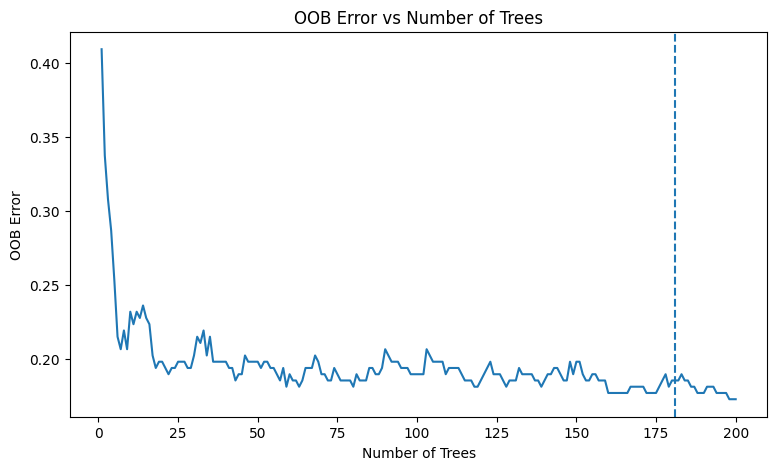

OOB error approximately stabilises near 181 trees.


In [38]:
oob_errors = []
tree_range = range(1, 201)

for n in tree_range:
    rf_temp = RandomForestClassifier(
        n_estimators=n,
        oob_score=True,
        bootstrap=True,
        random_state=42,
        n_jobs=-1
    )
    rf_temp.fit(X_train, y_train)
    oob_errors.append(1 - rf_temp.oob_score_)

# Approximate stabilization point
stabilise_point = np.argmin(np.abs(np.diff(oob_errors[-20:]))) + 181

plt.figure(figsize=(9, 5))
plt.plot(tree_range, oob_errors)
plt.axvline(stabilise_point, linestyle='--')
plt.xlabel("Number of Trees")
plt.ylabel("OOB Error")
plt.title("OOB Error vs Number of Trees")
plt.show()

print(f"OOB error approximately stabilises near {stabilise_point} trees.")

FEATURE IMPORTANCE

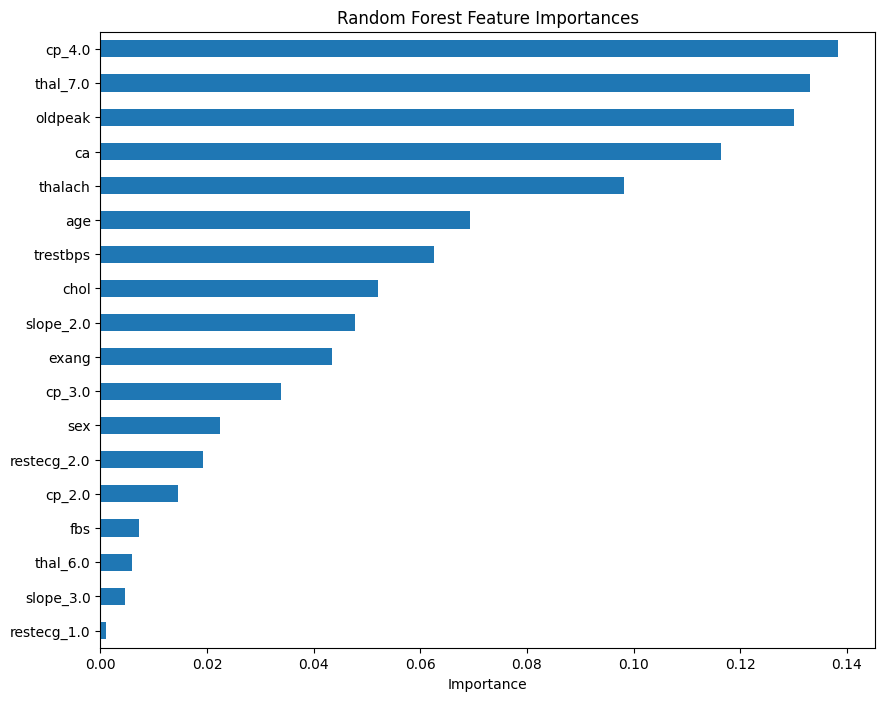


Top 5 Features:
cp_4.0      0.138402
thal_7.0    0.132990
oldpeak     0.130083
ca          0.116333
thalach     0.098242
dtype: float64


In [39]:
importances = pd.Series(
    best_rf.feature_importances_,
    index=X_train.columns
).sort_values()

plt.figure(figsize=(10, 8))
importances.plot(kind='barh')
plt.title("Random Forest Feature Importances")
plt.xlabel("Importance")
plt.show()

top5 = importances.sort_values(ascending=False).head(5)

print("\nTop 5 Features:")
print(top5)

TEST SET EVALUATION

In [40]:
y_pred = best_rf.predict(X_test)
y_prob = best_rf.predict_proba(X_test)[:, 1]

acc = accuracy_score(y_test, y_pred)
prec = precision_score(y_test, y_pred, average='macro')
rec = recall_score(y_test, y_pred, average='macro')
f1 = f1_score(y_test, y_pred, average='macro')
auc = roc_auc_score(y_test, y_prob)

print("\n=== Random Forest Test Metrics ===")
print(f"Accuracy        : {acc:.4f}")
print(f"Macro Precision : {prec:.4f}")
print(f"Macro Recall    : {rec:.4f}")
print(f"Macro F1        : {f1:.4f}")
print(f"AUC-ROC         : {auc:.4f}")


=== Random Forest Test Metrics ===
Accuracy        : 0.8167
Macro Precision : 0.8200
Macro Recall    : 0.8125
Macro F1        : 0.8141
AUC-ROC         : 0.9353


CONFUSION MATRIX


Confusion Matrix:
[[28  4]
 [ 7 21]]


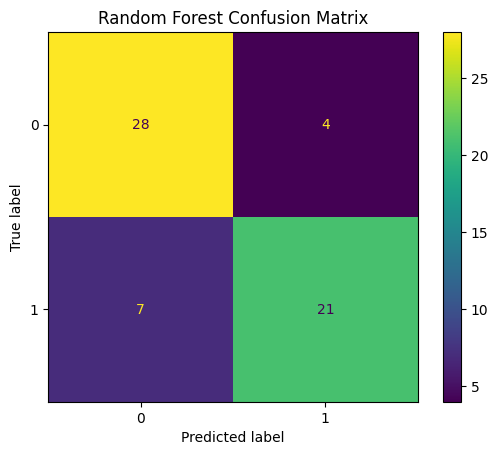

In [41]:
cm = confusion_matrix(y_test, y_pred)

print("\nConfusion Matrix:")
print(cm)

ConfusionMatrixDisplay(cm).plot()
plt.title("Random Forest Confusion Matrix")
plt.show()

CLASS-WISE RECALL

In [42]:
cm = confusion_matrix(y_test, y_pred)

recall_class0 = cm[0, 0] / cm[0].sum()
recall_class1 = cm[1, 1] / cm[1].sum()

print(f"\nRecall (No disease): {recall_class0:.4f}")
print(f"Recall (Disease)   : {recall_class1:.4f}")


Recall (No disease): 0.8750
Recall (Disease)   : 0.7500


B2  — GRADIENT BOOSTING (XGBOOST)

HYPERPARAMETER TUNING (5-FOLD CV)

In [44]:
print("Model used: XGBoost")

param_grid = {
    "learning_rate": [0.01, 0.1, 0.3],
    "max_depth": [3, 5, 7]
}

xgb_base = XGBClassifier(
    objective='binary:logistic',
    eval_metric='logloss',
    random_state=42
)

grid = GridSearchCV(
    estimator=xgb_base,
    param_grid=param_grid,
    scoring='f1_macro',
    cv=5,
    n_jobs=-1
)

grid.fit(X_train, y_train)

print("Best Parameters:", grid.best_params_)
print("Best CV F1:", grid.best_score_)

best_lr = grid.best_params_['learning_rate']
best_depth = grid.best_params_['max_depth']

Model used: XGBoost
Best Parameters: {'learning_rate': 0.1, 'max_depth': 7}
Best CV F1: 0.8236868806190472


TRAIN/VALIDATION SPLIT FOR EARLY STOPPING

In [45]:
X_tr, X_val, y_tr, y_val = train_test_split(
    X_train,
    y_train,
    test_size=0.2,
    random_state=42,
    stratify=y_train
)

FINAL MODEL WITH EARLY STOPPING

In [46]:
xgb_final = XGBClassifier(
    objective='binary:logistic',
    learning_rate=best_lr,
    max_depth=best_depth,
    n_estimators=500,
    eval_metric='logloss',
    early_stopping_rounds=50,
    random_state=42
)

xgb_final.fit(
    X_tr,
    y_tr,
    eval_set=[(X_tr, y_tr), (X_val, y_val)],
    verbose=False
)

,"objective objective: typing.Union[str, xgboost.sklearn._SklObjWProto, typing.Callable[[typing.Any, typing.Any], typing.Tuple[numpy.ndarray, numpy.ndarray]], NoneType]Specify the learning task and the corresponding learning objective or a customobjective function to be used.For custom objective, see :doc:`/tutorials/custom_metric_obj` and:ref:`custom-obj-metric` for more information, along with the end note forfunction signatures.",'binary:logistic'
,"base_score base_score: typing.Union[float, typing.List[float], NoneType]The initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.Optional[typing.List[xgboost.callback.TrainingCallback]]List of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API `... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: typing.Optional[float]Subsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: typing.Optional[float]Subsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: typing.Optional[float]Subsample ratio of columns when constructing each tree.,None
,"device device: typing.Optional[str].. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: typing.Optional[int].. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",50
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,False
,"eval_metric eval_metric: typing.Union[str, typing.List[typing.Union[str, typing.Callable]], typing.Callable, NoneType].. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes fr

TRAINING / VALIDATION LOG-LOSS

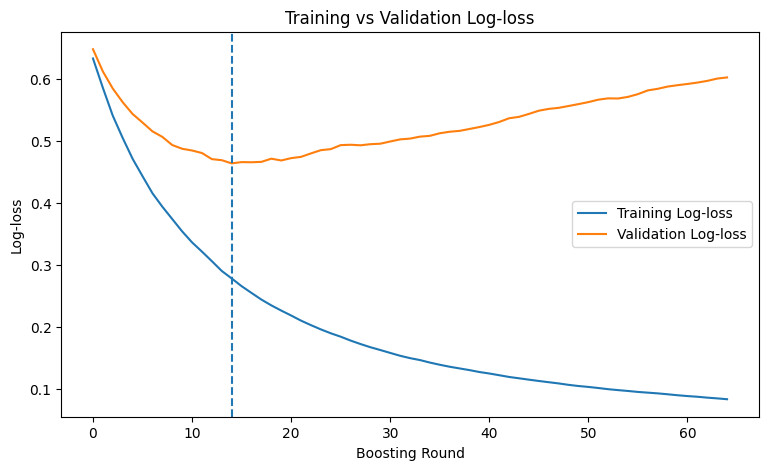

Best boosting round: 14


In [47]:
results = xgb_final.evals_result()

train_loss = results['validation_0']['logloss']
val_loss = results['validation_1']['logloss']

best_round = xgb_final.best_iteration

plt.figure(figsize=(9, 5))
plt.plot(train_loss, label='Training Log-loss')
plt.plot(val_loss, label='Validation Log-loss')
plt.axvline(best_round, linestyle='--')
plt.xlabel("Boosting Round")
plt.ylabel("Log-loss")
plt.title("Training vs Validation Log-loss")
plt.legend()
plt.show()

print("Best boosting round:", best_round)

SHAP Values

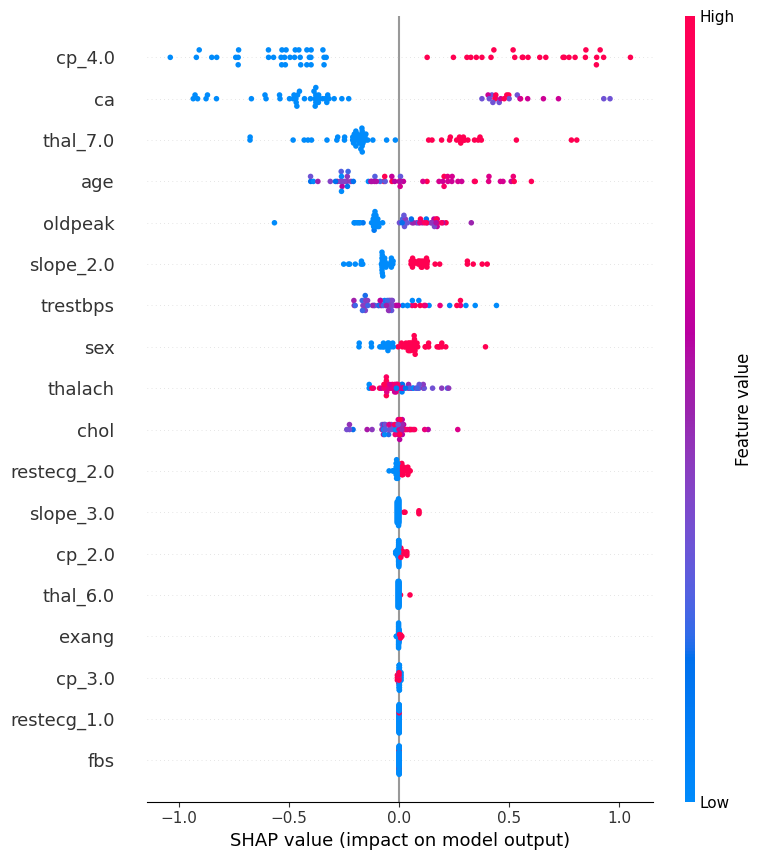

In [50]:
explainer = shap.TreeExplainer(xgb_final)
shap_values = explainer.shap_values(X_test)

shap.summary_plot(shap_values, X_test)

TEST SET EVALUATION

In [51]:
y_pred = xgb_final.predict(X_test)
y_prob = xgb_final.predict_proba(X_test)[:, 1]

acc = accuracy_score(y_test, y_pred)
prec = precision_score(y_test, y_pred, average='macro')
rec = recall_score(y_test, y_pred, average='macro')
f1 = f1_score(y_test, y_pred, average='macro')
auc = roc_auc_score(y_test, y_prob)

print("\n=== XGBoost Test Metrics ===")
print(f"Accuracy        : {acc:.4f}")
print(f"Macro Precision : {prec:.4f}")
print(f"Macro Recall    : {rec:.4f}")
print(f"Macro F1        : {f1:.4f}")
print(f"AUC-ROC         : {auc:.4f}")


=== XGBoost Test Metrics ===
Accuracy        : 0.7667
Macro Precision : 0.7775
Macro Recall    : 0.7589
Macro F1        : 0.7600
AUC-ROC         : 0.9107


CONFUSION MATRIX


Confusion Matrix:
[[28  4]
 [10 18]]


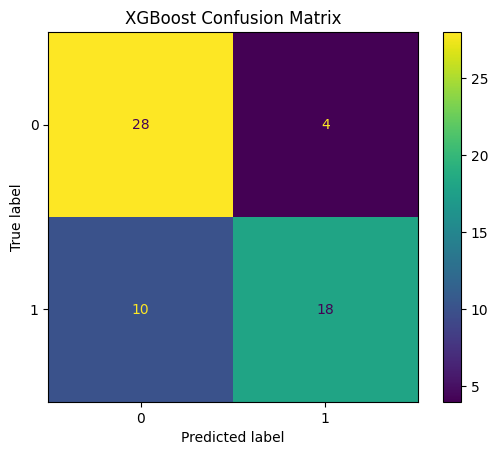

In [52]:
cm = confusion_matrix(y_test, y_pred)

print("\nConfusion Matrix:")
print(cm)

ConfusionMatrixDisplay(cm).plot()
plt.title("XGBoost Confusion Matrix")
plt.show()

B3 ENSEMBLE COMPARISON & ROC

FUNCTION TO EVALUATE MODELS

In [ ]:
best_a3_name = "Logistic Regression"

best_a3_model = LogisticRegression(
    max_iter=1000,
    random_state=42
)

EVALUATION FUNCTION

In [62]:
def evaluate_model(model, X_test, y_test):
    y_pred = model.predict(X_test)
    y_prob = model.predict_proba(X_test)[:, 1]

    accuracy = accuracy_score(y_test, y_pred)
    macro_f1 = f1_score(y_test, y_pred, average='macro')
    auc = roc_auc_score(y_test, y_prob)
    recall_disease = recall_score(y_test, y_pred, pos_label=1)

    return accuracy, macro_f1, auc, recall_disease, y_prob

LOGISTIC REGRESSION

In [ ]:
X_train_lr = X_train.astype(float)
X_test_lr = X_test.astype(float)

y_train_lr = np.ravel(y_train)
y_test_lr = np.ravel(y_test)

start = time.time()
best_a3_model.fit(X_train_lr, y_train_lr)
best_a3_time = time.time() - start

a3_acc, a3_f1, a3_auc, a3_rec, a3_prob = evaluate_model(
    best_a3_model,
    X_test_lr,
    y_test_lr
)

print(a3_acc, a3_f1, a3_auc, a3_rec, best_a3_time)

0.8666666666666667 0.8653198653198653 0.9497767857142857 0.8214285714285714 0.025094270706176758


RANDOM FOREST

In [68]:
start = time.time()
best_rf.fit(X_train, y_train)
rf_time = time.time() - start

rf_acc, rf_f1, rf_auc, rf_rec, rf_prob = evaluate_model(
    best_rf, X_test, y_test
)

XGBOOST
xgb_final is already trained in B2

In [70]:
xgb_time = np.nan

xgb_acc, xgb_f1, xgb_auc, xgb_rec, xgb_prob = evaluate_model(
    xgb_final, X_test, y_test
)

COMPARISON TABLE

In [75]:
comparison = pd.DataFrame({
    "Classifier": [
        best_a3_name,
        "Random Forest",
        "XGBoost"
    ],
    "Accuracy": [
        a3_acc,
        rf_acc,
        xgb_acc
    ],
    "Macro F1": [
        a3_f1,
        rf_f1,
        xgb_f1
    ],
    "AUC-ROC": [
        a3_auc,
        rf_auc,
        xgb_auc
    ],
    "Recall (Disease)": [
        a3_rec,
        rf_rec,
        xgb_rec
    ],
    "Train Time": [
        best_a3_time,
        rf_time,
        xgb_time
    ]
})

print("\nComparison Table:")
print(comparison)


Comparison Table:
      Classifier  Accuracy  Macro F1   AUC-ROC  Recall (Disease)  Train Time
0            KNN  0.866667  0.865320  0.949777          0.821429    0.025094
1  Random Forest  0.816667  0.814137  0.935268          0.750000    0.336563
2        XGBoost  0.766667  0.760000  0.910714          0.642857         NaN


ROC CURVES

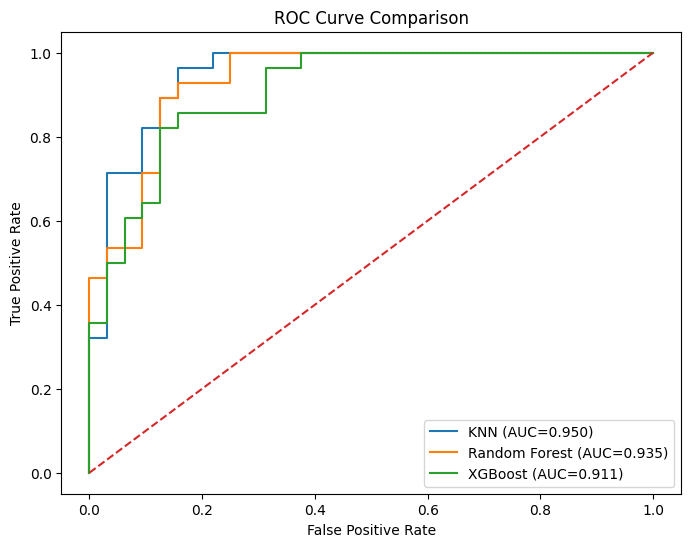

In [76]:
plt.figure(figsize=(8, 6))

fpr, tpr, _ = roc_curve(y_test, a3_prob)
plt.plot(fpr, tpr, label=f"{best_a3_name} (AUC={a3_auc:.3f})")

fpr, tpr, _ = roc_curve(y_test, rf_prob)
plt.plot(fpr, tpr, label=f"Random Forest (AUC={rf_auc:.3f})")

fpr, tpr, _ = roc_curve(y_test, xgb_prob)
plt.plot(fpr, tpr, label=f"XGBoost (AUC={xgb_auc:.3f})")

plt.plot([0, 1], [0, 1], linestyle='--')

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve Comparison")
plt.legend()
plt.show()